In [2]:
# End-to-End Customer Analytics & Revenue Forecasting Using Python

## Project Overview
# This project analyzes customer subscription data to understand customer behavior, revenue patterns, and churn.
# The project includes data cleaning, feature engineering, exploratory data analysis (EDA), data visualization, and machine learning.
# A Linear Regression model is developed to predict customer total revenue based on customer and subscription characteristics.

## Business Objectives
#- Analyze customer revenue patterns
#- Understand customer churn
#- Identify relationships between customer tenure and revenue
#- Analyze subscription plans and marketing channels
#- Identify important factors associated with revenue
#- Build a machine learning model to predict customer revenue

## Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Dataset](#2-load-dataset)
3. [Data Understanding](#3-data-understanding)
4. [Data Cleaning](#4-data-cleaning)
5. [Feature Engineering](#5-feature-engineering)
6. [Exploratory Data Analysis](#6-exploratory-data-analysis)
7. [Business Insights](#7-business-insights)
8. [Machine Learning](#8-machine-learning)
9. [Model Evaluation](#9-model-evaluation)
10. [Feature Importance](#10-feature-importance)
11. [Final Conclusions](#11-final-conclusions)

# 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
The customer subscription dataset is loaded using Pandas for further analysis.

In [4]:
df=pd.read_csv("subscription_data.csv")
df.head()

,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.0,Referral,No,3092.85
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.0,Organic,No,2180.00
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90


# 3. Data Understanding
#The dataset was initially examined to understand its structure, columns, data types, missing values, #duplicate records, and basic statistical characteristics.

In [5]:
df.shape
df.dtypes

customer_id            int64
age                  float64
gender                   str
city                     str
signup_date              str
last_active_date         str
plan_type                str
monthly_fee            int64
tenure_months          int64
support_tickets        int64
avg_session_time     float64
discount_percent     float64
marketing_channel        str
churned                  str
total_revenue        float64
dtype: object

In [6]:
df.isnull().sum()

customer_id            0
age                  105
gender                 0
city                 104
signup_date            0
last_active_date       0
plan_type              0
monthly_fee            0
tenure_months          0
support_tickets        0
avg_session_time     101
discount_percent     105
marketing_channel      0
churned                0
total_revenue          0
dtype: int64

In [7]:
(df.isnull().sum()/df.shape[0]*100)

customer_id          0.000000
age                  4.101562
gender               0.000000
city                 4.062500
signup_date          0.000000
last_active_date     0.000000
plan_type            0.000000
monthly_fee          0.000000
tenure_months        0.000000
support_tickets      0.000000
avg_session_time     3.945312
discount_percent     4.101562
marketing_channel    0.000000
churned              0.000000
total_revenue        0.000000
dtype: float64

## 4 Missing Values
#Missing values were identified using `isnull().sum()`.
#The missing values were handled based on the nature of each column.

In [8]:
#handleing the missing valuse in age column 
df['age'].describe()

count    2455.000000
mean       41.155193
std        13.558198
min        18.000000
25%        29.000000
50%        41.000000
75%        53.000000
max        64.000000
Name: age, dtype: float64

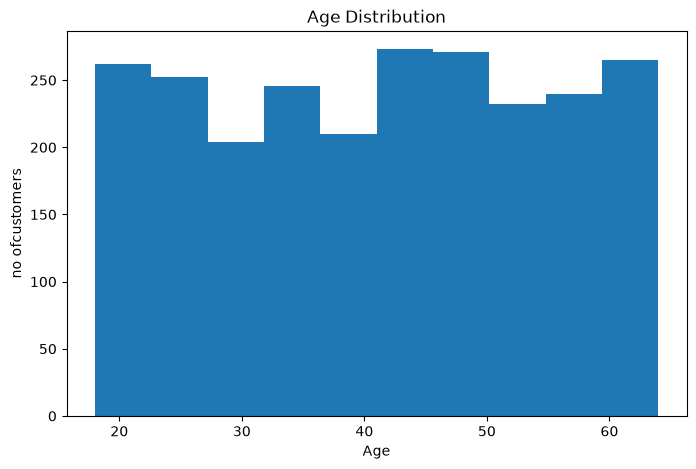

In [9]:
#chacking the age distribution with "histogram" 
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["age"],bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("no ofcustomers")
plt.show()

In [10]:
#after checking the histogram or mean and median you can choose
#mean or median , choosethe better one 
# after choosing that fill that in NaN of age place

df["age"]=df["age"].fillna(df["age"].median())

#after that check the Nan values
df["age"].isnull().sum()

np.int64(0)

In [11]:
df["city"].value_counts()

city
Mumbai       465
Hyderabad    410
Chennai      403
Pune         399
Bangalore    395
Delhi        384
Name: count, dtype: int64

In [12]:
#fillthe missing valusin city with "unknown"
df["city"]=df["city"].fillna("unknown")
df["city"].isnull().sum()

np.int64(0)

In [13]:
#now handle the avg session time column missing data 
#but before that using discibr ckeck that column
df["avg_session_time"].describe()
#the mean and median are extreamly close so choosing mean or median can do 

count    2459.000000
mean       62.719569
std        32.920546
min         5.130000
25%        34.570000
50%        62.590000
75%        90.650000
max       119.940000
Name: avg_session_time, dtype: float64

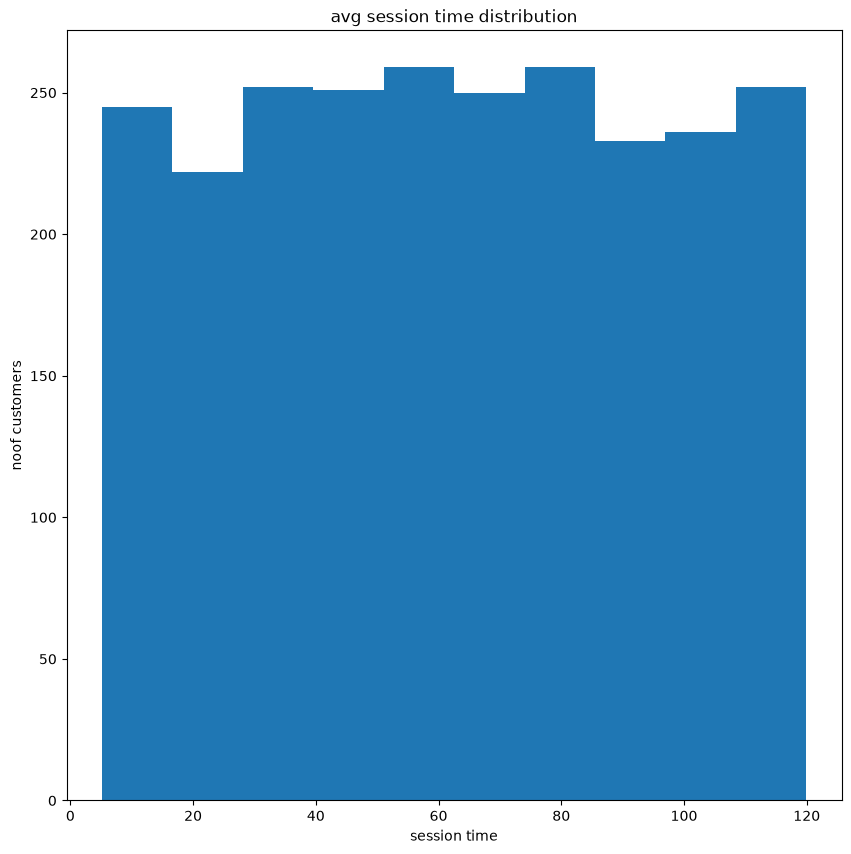

In [14]:
#the mean and median are extreamly close so choosing mean or median can do
#but checking with histogram
plt.figure(figsize=(10,10))
plt.hist(df["avg_session_time"],bins=10)
plt.title("avg session time distribution")
plt.xlabel("session time")
plt.ylabel("noof customers")
plt.show()

In [15]:
#now by choosing median  fillthat median in missing data places
df["avg_session_time"]=df["avg_session_time"].fillna(df["avg_session_time"].median())

In [16]:
# discount_percentage colummissing data handleing
df["discount_percent"].describe()

count    2455.000000
mean       10.024440
std         7.096911
min         0.000000
25%         5.000000
50%        10.000000
75%        15.000000
max        20.000000
Name: discount_percent, dtype: float64

In [17]:
df["discount_percent"]=df["discount_percent"].fillna(df["discount_percent"].median())

### Missing Value Treatment

#- Numerical variables were imputed using their median values.
#- Missing city values were replaced with `"Unknown"`.
#- Median imputation helps retain records while reducing the influence of extreme values.

In [18]:
#handleing the missing datis over now chwck again if is there any missing data valusin DF
df.isnull().sum()

customer_id          0
age                  0
gender               0
city                 0
signup_date          0
last_active_date     0
plan_type            0
monthly_fee          0
tenure_months        0
support_tickets      0
avg_session_time     0
discount_percent     0
marketing_channel    0
churned              0
total_revenue        0
dtype: int64

# 4.2 Data Cleaning

#The dataset was checked for duplicate records, missing values, incorrect data types, and inconsistent date #relationships.

#The cleaning process was performed to improve data quality before exploratory analysis and machine learning.

In [19]:
#checking duplicates
df.duplicated().sum()

np.int64(60)

In [20]:
df=df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df[['signup_date', 'last_active_date']].head()

,signup_date,last_active_date
0,12/3/2022,12/29/2022
1,3/24/2021,1/25/2022
2,6/15/2023,8/10/2023
3,11/13/2022,7/8/2021
4,2/17/2022,6/25/2021


In [23]:
df.dtypes

customer_id            int64
age                  float64
gender                   str
city                     str
signup_date              str
last_active_date         str
plan_type                str
monthly_fee            int64
tenure_months          int64
support_tickets        int64
avg_session_time     float64
discount_percent     float64
marketing_channel        str
churned                  str
total_revenue        float64
dtype: object

## 4.3 Date Conversion

#The signup and last active date columns were converted from string values into Pandas datetime format.

In [24]:
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["last_active_date"]=pd.to_datetime(df["last_active_date"])

In [25]:
df['signup_date'].dtype

dtype('<M8[us]')

In [26]:
(df['last_active_date'] < df['signup_date']).sum()

np.int64(852)

## 4.4 Date Consistency Check

#The relationship between signup date and last active date was checked to identify records where the last #active date occurred before the signup date.

In [27]:
df[df['last_active_date'] < df['signup_date']][
    ['customer_id', 'signup_date', 'last_active_date']
].head(10)

,customer_id,signup_date,last_active_date
3,10004,2022-11-13,2021-07-08
4,10005,2022-02-17,2021-06-25
6,10007,2022-12-01,2022-09-04
8,10009,2023-03-12,2022-07-22
10,10011,2022-09-01,2022-06-18
12,10013,2022-06-12,2021-11-05
13,10014,2023-03-02,2022-12-21
14,10015,2022-10-09,2022-08-07
15,10016,2022-06-22,2021-07-18
16,10017,2023-05-14,2022-04-24


In [28]:
invalid_dates = (df['last_active_date'] < df['signup_date']).sum()

invalid_percentage = invalid_dates / len(df) * 100

invalid_percentage

df[['signup_date', 'last_active_date']].describe()

,signup_date,last_active_date
count,2500,2500
mean,2022-04-01 07:04:30.720000,2022-09-03 10:59:31.200000
min,2021-01-01 00:00:00,2021-06-01 00:00:00
25%,2021-08-16 00:00:00,2022-01-21 00:00:00
50%,2022-03-26 00:00:00,2022-09-13 12:00:00
75%,2022-11-22 06:00:00,2023-04-16 00:00:00
max,2023-06-19 00:00:00,2023-11-17 00:00:00


### Finding
852 records had a last active date earlier than the signup date. These records were retained in the dataset rather than deleted, and the date inconsistency was tracked using a validation flag.
The `days_active` feature was not used in the initial revenue prediction model because these inconsistent dates could produce invalid negative durations.

In [29]:
#so the data in 852 row are in correct i.e the last active date is earler than signupdate 
# so deleting thos data rows may cause data loss
# so remain it same but dont use operation that useses these data
#now lets creat a column that show thw valid dated colums 
df["valid_date_order "]=df["last_active_date"]>=df["signup_date"]
#then check the valid date oder ones and not ones
df["valid_date_order "].value_counts()

valid_date_order 
True     1648
False     852
Name: count, dtype: int64

## 4.5 Cleaning Verification

In [30]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

Rows: 2500
Columns: 16
Duplicate rows: 0


In [31]:
df[['age', 'monthly_fee', 'tenure_months', 
    'support_tickets', 'avg_session_time',
    'discount_percent', 'total_revenue']].describe()

,age,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,total_revenue
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000
mean,41.13280,902.536000,17.784000,2.089600,62.645964,10.024000,15909.88380
std,13.29157,348.080219,10.062736,1.478122,32.239271,6.942529,11366.85225
min,18.00000,300.000000,1.000000,0.000000,5.130000,0.000000,288.15000
25%,30.00000,593.000000,9.000000,1.000000,35.480000,5.000000,6889.05000
50%,41.00000,911.500000,17.000000,2.000000,62.590000,10.000000,13457.82500
75%,52.00000,1205.000000,26.000000,3.000000,88.905000,15.000000,23251.37500
max,64.00000,1499.000000,35.000000,8.000000,119.940000,20.000000,50741.60000


# 5. Feature Engineering

New features were created from the existing customer data to improve customer segmentation, behavioral analysis, and revenue analysis.

In [32]:
# lets start with EDA(Exploratory data Analysis)
df["churned"].value_counts()

churned
No     1914
Yes     586
Name: count, dtype: int64

## 5.0 Churn Features

In [33]:
#calculate churn rate ((no of yes churned/total churned valuse)*100)
churn_rate = (df['churned'] == 'Yes').mean() * 100

churn_rate

np.float64(23.44)

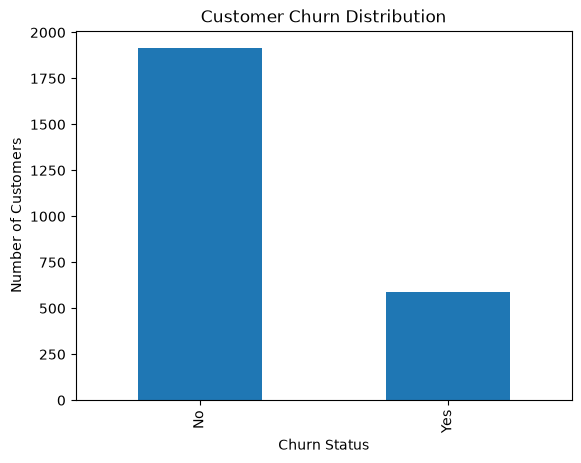

In [34]:
df['churned'].value_counts().plot(kind='bar')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [35]:
# finding out  why the customers churned
#to find lets compare with different  factors
# churn VS paln type
# cross tab is pands function that is comaper two categories and count their combinations
pd.crosstab(df["plan_type"],df["churned"])

churned,No,Yes
plan_type,,
Basic,834,267
Premium,359,130
Standard,721,189


In [36]:
# finding percentage of churned people
pd.crosstab(df["plan_type"],df["churned"],normalize="index")*100

churned,No,Yes
plan_type,,
Basic,75.749319,24.250681
Premium,73.415133,26.584867
Standard,79.230769,20.769231


In [37]:
#creating table 
import pandas as pd
df=pd.read_csv("subscription_data.csv")
churn_by_plan = pd.crosstab(df["plan_type"],df["churned"],normalize="index")*100
churn_by_plan

churned,No,Yes
plan_type,,
Basic,75.668449,24.331551
Premium,72.763419,27.236581
Standard,79.358289,20.641711


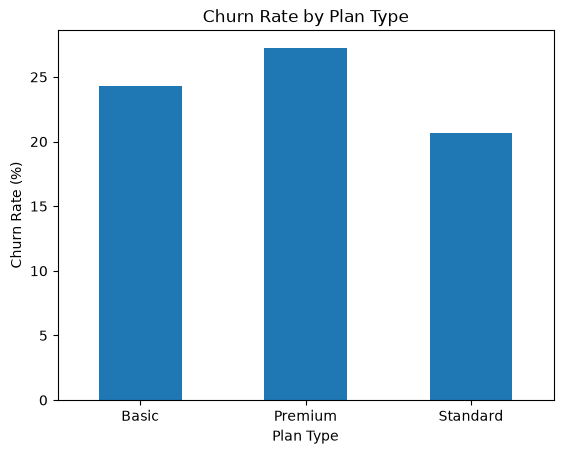

In [101]:
#creating a bar chart
churn_by_plan["Yes"].plot(kind="bar")

plt.title("Churn Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.savefig("images/churn_rate_by_plantype.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.1 Customer Tenure

In [39]:
#creating customer tenure years column(calculating years from tenure months)
df["cus_temure_years"]=df["tenure_months"]/12
df

,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue,cus_temure_years
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90,2.083333
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40,1.833333
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.0,Referral,No,3092.85,0.333333
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.0,Organic,No,2180.00,0.333333
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90,2.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,11315,61.0,Male,Bangalore,11/17/2021,10/15/2022,Basic,1194,17,1,78.57,20.0,Organic,No,20059.20,1.416667
2556,10645,25.0,Female,Pune,1/15/2022,11/3/2023,Basic,1016,18,2,9.21,NaN,Email,No,18288.00,1.500000
2557,12103,25.0,Female,Chennai,1/21/2022,8/14/2022,Premium,801,20,1,11.67,20.0,Organic,No,15859.80,1.666667
2558,10615,NaN,Female,Pune,3/17/2022,10/7/2023,Premium,692,22,0,34.42,0.0,Ads,No,15224.00,1.833333


## 5.2 Revenue-Based Features

In [40]:
#Creating a revenue_per_month column (Create a column Total rev / Tenure months)
df["revenue_per_month"]=df["total_revenue"]/df["tenure_months"]
df

,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue,cus_temure_years,revenue_per_month
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90,2.083333,1206.716000
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40,1.833333,1256.472727
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.0,Referral,No,3092.85,0.333333,773.212500
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.0,Organic,No,2180.00,0.333333,545.000000
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90,2.500000,1326.563333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,11315,61.0,Male,Bangalore,11/17/2021,10/15/2022,Basic,1194,17,1,78.57,20.0,Organic,No,20059.20,1.416667,1179.952941
2556,10645,25.0,Female,Pune,1/15/2022,11/3/2023,Basic,1016,18,2,9.21,NaN,Email,No,18288.00,1.500000,1016.000000
2557,12103,25.0,Female,Chennai,1/21/2022,8/14/2022,Premium,801,20,1,11.67,20.0,Organic,No,15859.80,1.666667,792.990000
2558,10615,NaN,Female,Pune,3/17/2022,10/7/2023,Premium,692,22,0,34.42,0.0,Ads,No,15224.00,1.833333,692.000000


In [41]:
#Calculating total revenue by plan
revenue_by_plan= df.groupby("plan_type")["total_revenue"].sum()
revenue_by_plan

plan_type
Basic       17441232.40
Premium      7904098.75
Standard    15389981.95
Name: total_revenue, dtype: float64

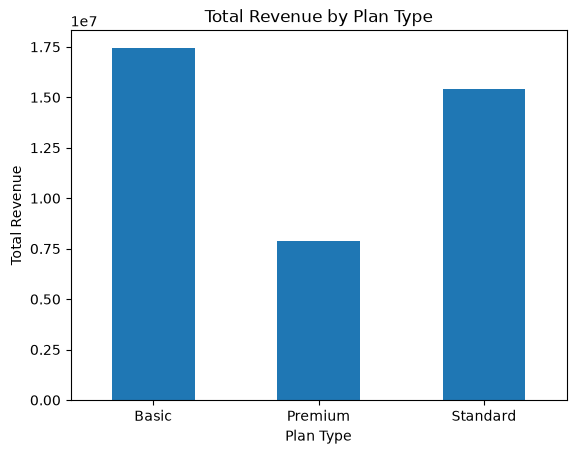

In [100]:
#creating a bar chart 
revenue_by_plan.plot(kind="bar")

plt.title("Total Revenue by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.savefig("images/revenue_by_plantype.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
#calculating avg revenue by customer 
#because total revenu may miss lead because there are diff no of customers per plan
average_revenue_by_plan = df.groupby("plan_type")["total_revenue"].mean()

average_revenue_by_plan

plan_type
Basic       15544.770410
Premium     15713.914016
Standard    16459.873743
Name: total_revenue, dtype: float64

In [44]:
revenue_by_channel = df.groupby("marketing_channel")["total_revenue"].sum()

revenue_by_channel

marketing_channel
Ads          9542287.4
Email       10765910.5
Organic     10375935.1
Referral    10051180.1
Name: total_revenue, dtype: float64

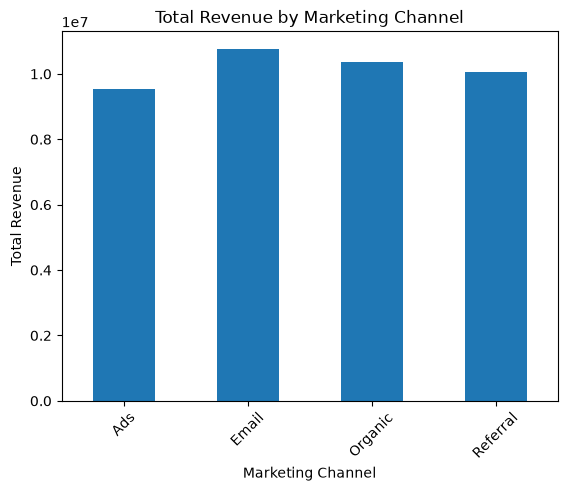

In [99]:
#creating the bar chart for revenue_by_channel
revenue_by_channel.plot(kind="bar")

plt.title("Total Revenue by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.savefig("images/revenue_by_channel.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
revenue_by_channel.sort_values(ascending=False)

marketing_channel
Email       10765910.5
Organic     10375935.1
Referral    10051180.1
Ads          9542287.4
Name: total_revenue, dtype: float64

In [47]:
#revenue by citie (top 5)
revenue_by_city=df.groupby("city")["total_revenue"].sum()
revenue_by_city
top_5_cities=revenue_by_city.sort_values(ascending=False).head(5)
top_5_cities

city
Mumbai       7566976.75
Hyderabad    6490572.15
Bangalore    6291584.75
Pune         6287431.25
Chennai      6236053.95
Name: total_revenue, dtype: float64

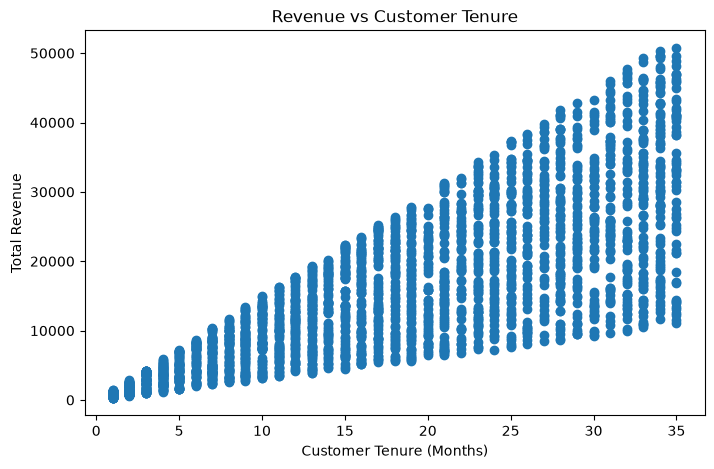

In [48]:
#checking  revenue  vs customer tenure
#is ther a relation b/w customer tenure and total revenue
#checking with scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(
    df["tenure_months"],
    df["total_revenue"]
)

plt.title("Revenue vs Customer Tenure")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Total Revenue")

plt.show()

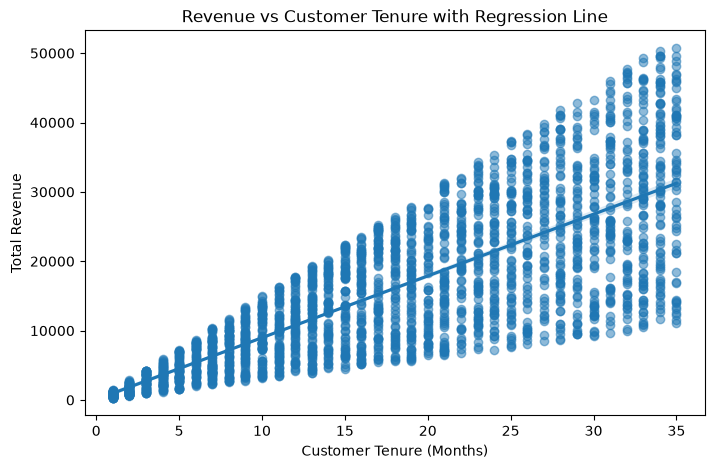

In [98]:
#regression line chart
# this regression line indicates its +or - relation
plt.figure(figsize=(8,5))
sns.regplot(data=df,
            x="tenure_months",
            y="total_revenue",
            scatter_kws={"alpha":0.5})
plt.title("Revenue vs Customer Tenure with Regression Line")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Total Revenue")

plt.savefig("images/revenue_vs_tenure.png", dpi=300, bbox_inches="tight")

plt.show()

## 5.3 Engagement Score

In [50]:
df["engagement_score"] = (
    df["avg_session_time"] / (df["support_tickets"] + 1)
)
df

,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue,cus_temure_years,revenue_per_month,engagement_score
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90,2.083333,1206.716000,2.625000
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40,1.833333,1256.472727,18.580000
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.0,Referral,No,3092.85,0.333333,773.212500,41.930000
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.0,Organic,No,2180.00,0.333333,545.000000,58.205000
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90,2.500000,1326.563333,40.945000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,11315,61.0,Male,Bangalore,11/17/2021,10/15/2022,Basic,1194,17,1,78.57,20.0,Organic,No,20059.20,1.416667,1179.952941,39.285000
2556,10645,25.0,Female,Pune,1/15/2022,11/3/2023,Basic,1016,18,2,9.21,NaN,Email,No,18288.00,1.500000,1016.000000,3.070000
2557,12103,25.0,Female,Chennai,1/21/2022,8/14/2022,Premium,801,20,1,11.67,20.0,Organic,No,15859.80,1.666667,792.990000,5.835000
2558,10615,NaN,Female,Pune,3/17/2022,10/7/2023,Premium,692,22,0,34.42,0.0,Ads,No,15224.00,1.833333,692.000000,34.420000


In [51]:
df[["avg_session_time", "support_tickets", "engagement_score"]].head()

,avg_session_time,support_tickets,engagement_score
0,15.75,5,2.625
1,37.16,1,18.580
2,41.93,0,41.930
3,116.41,1,58.205
4,81.89,1,40.945


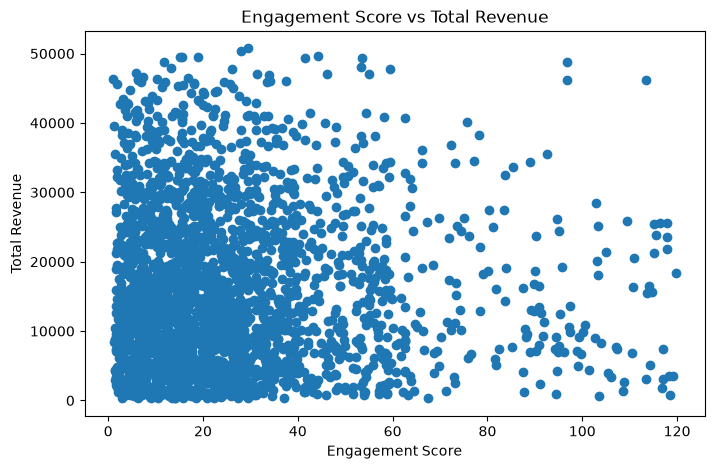

In [97]:
#engagement score vs revenue (scatter plot)
plt.figure(figsize=(8, 5))

plt.scatter(
    df["engagement_score"],
    df["total_revenue"]
)

plt.title("Engagement Score vs Total Revenue")
plt.xlabel("Engagement Score")
plt.ylabel("Total Revenue")
plt.savefig("images/engagement_vs_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

## 5.4 Date-Based Features

In [53]:


df["signup_date"] = pd.to_datetime(df["signup_date"])
df["signup_date"].dtype

dtype('<M8[us]')

In [54]:
df["signup_month"] = df["signup_date"].dt.to_period("M")
signup_trend=df.groupby("signup_date")["customer_id"].count()
signup_trend

signup_date
2021-01-01    2
2021-01-02    2
2021-01-03    2
2021-01-04    1
2021-01-06    3
             ..
2023-06-15    1
2023-06-16    2
2023-06-17    5
2023-06-18    3
2023-06-19    3
Name: customer_id, Length: 852, dtype: int64

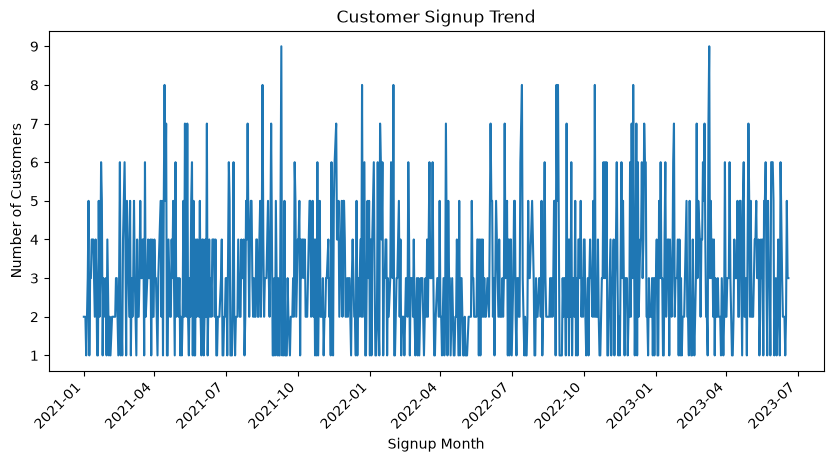

In [96]:
#signup trend chart(line)
signup_trend.plot(kind="line", figsize=(10, 5))

plt.title("Customer Signup Trend")
plt.xlabel("Signup Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.savefig("images/signup_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
df["revenue_month"] = df["signup_date"].dt.to_period("M")
monthly_revenue = df.groupby("revenue_month")["total_revenue"].sum()

monthly_revenue


revenue_month
2021-01    1341076.05
2021-02    1205321.90
2021-03    1376698.50
2021-04    1531610.65
2021-05    1385676.80
2021-06    1246340.50
2021-07    1426793.55
2021-08    1650978.80
2021-09    1072658.00
2021-10    1358865.55
2021-11    1561459.80
2021-12    1371528.15
2022-01    1532342.70
2022-02    1052229.40
2022-03    1253796.00
2022-04     975211.60
2022-05     873780.70
2022-06    1551477.05
2022-07    1229240.85
2022-08    1358525.90
2022-09    1242820.20
2022-10    1469014.30
2022-11    1265530.50
2022-12    1715666.70
2023-01    1493644.25
2023-02    1320297.95
2023-03    1609599.00
2023-04    1744297.30
2023-05    1831152.25
2023-06     687678.20
Freq: M, Name: total_revenue, dtype: float64

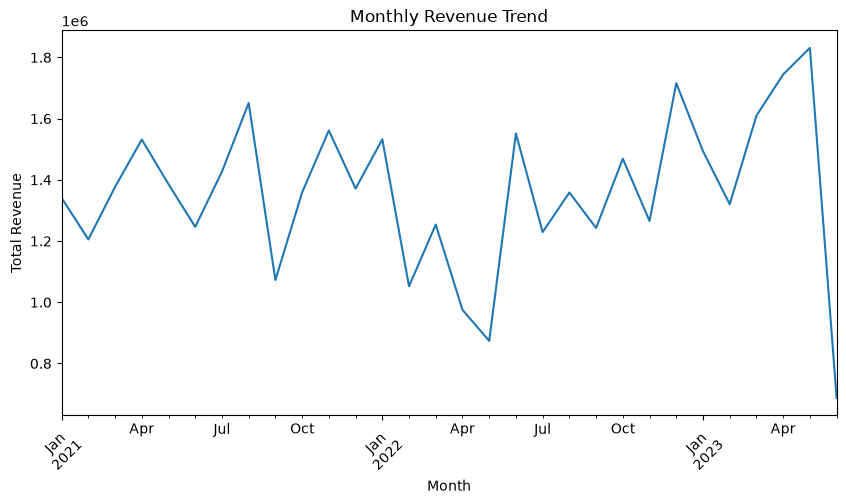

In [95]:
monthly_revenue.plot(kind="line", figsize=(10, 5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.savefig("images/monthly_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
#calculating correlation heatmap
# this helps to identify relation ships b/w variables such as(age,monthlyfee,tenure,diss%...etc)
#-select numerical columns
#calculate correlation
#corr= +1 then(strong +ve linear relationship ), -1(strong -ve linear relationship)
#0(weak or no linear relationship)
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

correlation_matrix


,customer_id,age,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,total_revenue,cus_temure_years,revenue_per_month,engagement_score
customer_id,1.000000,-0.002419,0.021296,-0.006403,0.001745,-0.014305,-0.042828,0.006229,-0.006403,0.023871,-0.024868
age,-0.002419,1.000000,0.007635,-0.012073,0.023754,0.077929,0.021245,0.004024,-0.012073,0.006320,0.047048
monthly_fee,0.021296,0.007635,1.000000,-0.014417,-0.019045,-0.010525,0.004624,0.525000,-0.014417,0.997423,-0.005596
tenure_months,-0.006403,-0.012073,-0.014417,1.000000,0.000790,-0.012400,-0.023908,0.787488,1.000000,0.017013,-0.016422
support_tickets,0.001745,0.023754,-0.019045,0.000790,1.000000,0.011139,-0.007827,-0.005860,0.000790,-0.017933,-0.570113
avg_session_time,-0.014305,0.077929,-0.010525,-0.012400,0.011139,1.000000,0.001164,-0.022093,-0.012400,-0.010230,0.621006
discount_percent,-0.042828,0.021245,0.004624,-0.023908,-0.007827,0.001164,1.000000,-0.024509,-0.023908,-0.019001,-0.002963
total_revenue,0.006229,0.004024,0.525000,0.787488,-0.005860,-0.022093,-0.024509,1.000000,0.787488,0.552852,-0.022497
cus_temure_years,-0.006403,-0.012073,-0.014417,1.000000,0.000790,-0.012400,-0.023908,0.787488,1.000000,0.017013,-0.016422
revenue_per_month,0.023871,0.006320,0.997423,0.017013,-0.017933,-0.010230,-0.019001,0.552852,0.017013,1.000000,-0.006485


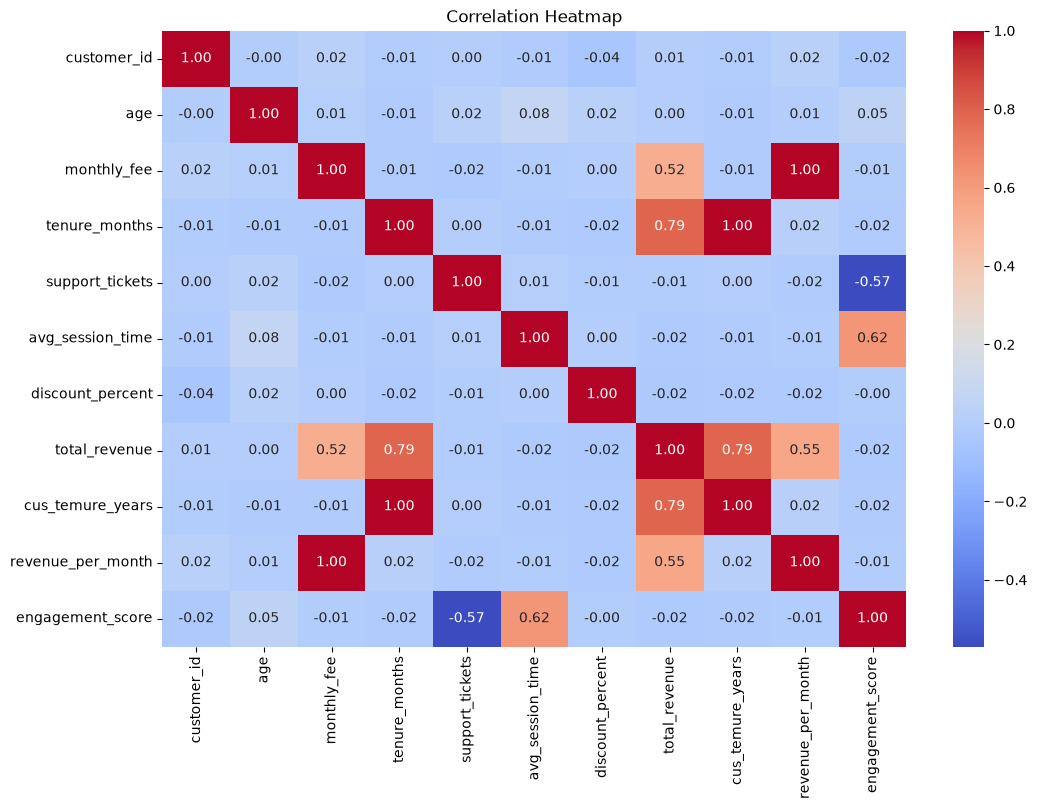

In [94]:
#heatmap correlation
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [60]:
df[[
    "monthly_fee",
    "tenure_months",
    "total_revenue",
    "revenue_per_month"
]].head(10)

,monthly_fee,tenure_months,total_revenue,revenue_per_month
0,1214,25,30167.90,1206.716000
1,1268,22,27642.40,1256.472727
2,783,4,3092.85,773.212500
3,545,4,2180.00,545.000000
4,1331,30,39796.90,1326.563333
5,451,2,834.35,417.175000
6,510,29,14790.00,510.000000
7,666,21,13886.10,661.242857
8,1243,21,25916.55,1234.121429
9,385,21,8027.25,382.250000


In [61]:
df[["monthly_fee", "revenue_per_month"]].describe()

,monthly_fee,revenue_per_month
count,2560.000000,2560.000000
mean,900.632422,889.430478
std,347.392614,343.653875
min,300.000000,288.150000
25%,592.750000,587.306250
50%,909.000000,894.337037
75%,1203.000000,1186.544488
max,1499.000000,1497.000000


In [62]:
df.shape
df=df.drop_duplicates()
df.duplicated().sum()
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

Shape: (2500, 20)
Duplicates: 0


In [63]:
#creating the colum age range
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 50, 64],
    labels=["Young", "Adult", "Middle-aged", "Older"]
)
#pd.cut() divides numerical values into predefined ranges
df[["age", "age_group"]].head(10)

,age,age_group
0,56.0,Older
1,46.0,Middle-aged
2,32.0,Adult
3,60.0,Older
4,25.0,Young
5,38.0,Middle-aged
6,56.0,Older
7,36.0,Middle-aged
8,40.0,Middle-aged
9,28.0,Adult


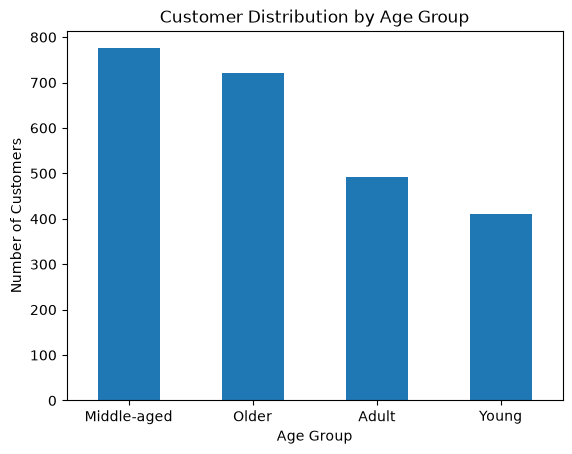

In [93]:
df["age_group"].value_counts()
df["age_group"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.savefig("images/customer_distribution_by_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

In [65]:
#using lambda function 
df["age_group_lambda"] = df["age"].apply(
    lambda x: "Young" if x <= 25
    else ("Middle" if x <= 45 else "Senior")
)
df[["age","age_group_lambda"]].head(5)

,age,age_group_lambda
0,56.0,Senior
1,46.0,Senior
2,32.0,Middle
3,60.0,Senior
4,25.0,Young


In [66]:
df["churned_flag"]= df["churned"].apply(lambda x : 1 if x =="Yes" else 0)

#or
df["churn_flag"] = df["churned"].map({
    "Yes": 1,
    "No": 0
})


In [67]:
#high value  customer
# take median as threshold
revenue_median=df["total_revenue"].median()
df["high_value_customer"]=df["total_revenue"].apply(lambda x:
                                                     "Yes" if x >= revenue_median else "No" )

In [68]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["last_active_date"] = pd.to_datetime(df["last_active_date"])
df["days_active"] = (
    df["last_active_date"] - df["signup_date"]
).dt.days

In [69]:
df[["signup_date", "last_active_date", "days_active"]].head(10)

,signup_date,last_active_date,days_active
0,2022-12-03,2022-12-29,26
1,2021-03-24,2022-01-25,307
2,2023-06-15,2023-08-10,56
3,2022-11-13,2021-07-08,-493
4,2022-02-17,2021-06-25,-237
5,2021-06-16,2022-07-15,394
6,2022-12-01,2022-09-04,-88
7,2021-06-18,2022-12-23,553
8,2023-03-12,2022-07-22,-233
9,2021-08-17,2022-05-23,279


In [70]:
#some days may give -ve because the dates data is incorrect
(df["days_active"] < 0).sum()


np.int64(852)

In [71]:
df[df["days_active"] < 0][
    ["signup_date", "last_active_date", "days_active"]
].head(10)

,signup_date,last_active_date,days_active
3,2022-11-13,2021-07-08,-493
4,2022-02-17,2021-06-25,-237
6,2022-12-01,2022-09-04,-88
8,2023-03-12,2022-07-22,-233
10,2022-09-01,2022-06-18,-75
12,2022-06-12,2021-11-05,-219
13,2023-03-02,2022-12-21,-71
14,2022-10-09,2022-08-07,-63
15,2022-06-22,2021-07-18,-339
16,2023-05-14,2022-04-24,-385


In [72]:
df["days_active"] = df["days_active"].where(
    df["days_active"] >= 0
)
df["days_active"].describe()
df.head(10)

,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,...,revenue_per_month,engagement_score,signup_month,revenue_month,age_group,age_group_lambda,churned_flag,churn_flag,high_value_customer,days_active
0,10001,56.0,Female,Chennai,2022-12-03,2022-12-29,Basic,1214,25,5,...,1206.716000,2.625000,2022-12,2022-12,Older,Senior,1,1,Yes,26.0
1,10002,46.0,Female,Mumbai,2021-03-24,2022-01-25,Premium,1268,22,1,...,1256.472727,18.580000,2021-03,2021-03,Middle-aged,Senior,1,1,Yes,307.0
2,10003,32.0,Female,Mumbai,2023-06-15,2023-08-10,Basic,783,4,0,...,773.212500,41.930000,2023-06,2023-06,Adult,Middle,0,0,No,56.0
3,10004,60.0,Male,Delhi,2022-11-13,2021-07-08,Standard,545,4,1,...,545.000000,58.205000,2022-11,2022-11,Older,Senior,0,0,No,NaN
4,10005,25.0,Female,Mumbai,2022-02-17,2021-06-25,Basic,1331,30,1,...,1326.563333,40.945000,2022-02,2022-02,Young,Young,0,0,Yes,NaN
5,10006,38.0,Male,Delhi,2021-06-16,2022-07-15,Standard,451,2,0,...,417.175000,53.990000,2021-06,2021-06,Middle-aged,Middle,0,0,No,394.0
6,10007,56.0,Male,Hyderabad,2022-12-01,2022-09-04,Basic,510,29,4,...,510.000000,23.726000,2022-12,2022-12,Older,Senior,1,1,Yes,NaN
7,10008,36.0,Female,Chennai,2021-06-18,2022-12-23,Basic,666,21,1,...,661.242857,11.310000,2021-06,2021-06,Middle-aged,Middle,0,0,Yes,553.0
8,10009,40.0,Male,Bangalore,2023-03-12,2022-07-22,Basic,1243,21,2,...,1234.121429,19.916667,2023-03,2023-03,Middle-aged,Middle,1,1,Yes,NaN
9,10010,28.0,Male,Chennai,2021-08-17,2022-05-23,Basic,385,21,4,...,382.250000,15.882000,2021-08,2021-08,Adult,Middle,0,0,No,279.0


In [73]:
#session usage category
#catagoriesing customers  based on session time
#<20--low, 20-60---medium, >60---high
#using  lambda function
df["session_usage_category"] = df["avg_session_time"].apply(
    lambda x: "Low" if x < 20
    else ("Medium" if x <= 60 else "High")
)

In [74]:
#using pandas cut
df["session_usage_cat"]=pd.cut(df["avg_session_time"],
                               bins=[5,20,60,500],
                               labels=["low","medium","high"])
df.head(10)             

,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,...,signup_month,revenue_month,age_group,age_group_lambda,churned_flag,churn_flag,high_value_customer,days_active,session_usage_category,session_usage_cat
0,10001,56.0,Female,Chennai,2022-12-03,2022-12-29,Basic,1214,25,5,...,2022-12,2022-12,Older,Senior,1,1,Yes,26.0,Low,low
1,10002,46.0,Female,Mumbai,2021-03-24,2022-01-25,Premium,1268,22,1,...,2021-03,2021-03,Middle-aged,Senior,1,1,Yes,307.0,Medium,medium
2,10003,32.0,Female,Mumbai,2023-06-15,2023-08-10,Basic,783,4,0,...,2023-06,2023-06,Adult,Middle,0,0,No,56.0,Medium,medium
3,10004,60.0,Male,Delhi,2022-11-13,2021-07-08,Standard,545,4,1,...,2022-11,2022-11,Older,Senior,0,0,No,NaN,High,high
4,10005,25.0,Female,Mumbai,2022-02-17,2021-06-25,Basic,1331,30,1,...,2022-02,2022-02,Young,Young,0,0,Yes,NaN,High,high
5,10006,38.0,Male,Delhi,2021-06-16,2022-07-15,Standard,451,2,0,...,2021-06,2021-06,Middle-aged,Middle,0,0,No,394.0,Medium,medium
6,10007,56.0,Male,Hyderabad,2022-12-01,2022-09-04,Basic,510,29,4,...,2022-12,2022-12,Older,Senior,1,1,Yes,NaN,High,high
7,10008,36.0,Female,Chennai,2021-06-18,2022-12-23,Basic,666,21,1,...,2021-06,2021-06,Middle-aged,Middle,0,0,Yes,553.0,Medium,medium
8,10009,40.0,Male,Bangalore,2023-03-12,2022-07-22,Basic,1243,21,2,...,2023-03,2023-03,Middle-aged,Middle,1,1,Yes,NaN,Medium,medium
9,10010,28.0,Male,Chennai,2021-08-17,2022-05-23,Basic,385,21,4,...,2021-08,2021-08,Adult,Middle,0,0,No,279.0,High,high


In [75]:
#discount category
df["discount_category"]=pd.cut(df["discount_percent"],
                               bins=[-float("inf"),10,25,float("inf")],
                               labels=["low","med","high"])
# -float("inf")=-infinte and  float("inf")= +infine ....so on 

In [76]:
#using lambda
df["dis_category"]=df["discount_percent"].apply(lambda x: "low" if x<20
                                                else("med" if x>=60 else "high"))
df.head(5)

,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,...,age_group,age_group_lambda,churned_flag,churn_flag,high_value_customer,days_active,session_usage_category,session_usage_cat,discount_category,dis_category
0,10001,56.0,Female,Chennai,2022-12-03,2022-12-29,Basic,1214,25,5,...,Older,Senior,1,1,Yes,26.0,Low,low,med,low
1,10002,46.0,Female,Mumbai,2021-03-24,2022-01-25,Premium,1268,22,1,...,Middle-aged,Senior,1,1,Yes,307.0,Medium,medium,med,high
2,10003,32.0,Female,Mumbai,2023-06-15,2023-08-10,Basic,783,4,0,...,Adult,Middle,0,0,No,56.0,Medium,medium,low,low
3,10004,60.0,Male,Delhi,2022-11-13,2021-07-08,Standard,545,4,1,...,Older,Senior,0,0,No,NaN,High,high,low,low
4,10005,25.0,Female,Mumbai,2022-02-17,2021-06-25,Basic,1331,30,1,...,Young,Young,0,0,Yes,NaN,High,high,low,low


In [77]:
#extracting sign upmonth
df["signup_month"] = df["signup_date"].dt.month

In [78]:
#support intensity
#=support ticket/(tenure moth+1)
df["support_intensity"] = (
    df["support_tickets"] / (df["tenure_months"] + 1)
)

In [79]:
#revenu category
#qcut  divides the data into aproximatly equal parts (q=3) so divides customer into 3 equal parts aproximatly
df["revenue_category"] = pd.qcut(
    df["total_revenue"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [80]:
#assign a numerical rank to each subscription plan. This helps us use plan information in calculations and machine learning.
#plan_rank is a Python dictionary that maps each plan to a number.
#.map(plan_rank) looks at every value in plan_type and replaces it with the matching number.
#The result is saved in the new plan_rank column.
plan_rank = {
    "Basic": 1,
    "Standard": 2,
    "Premium": 3
}

df["plan_rank"] = df["plan_type"].map(plan_rank)

In [81]:
df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'city',
 'signup_date',
 'last_active_date',
 'plan_type',
 'monthly_fee',
 'tenure_months',
 'support_tickets',
 'avg_session_time',
 'discount_percent',
 'marketing_channel',
 'churned',
 'total_revenue',
 'cus_temure_years',
 'revenue_per_month',
 'engagement_score',
 'signup_month',
 'revenue_month',
 'age_group',
 'age_group_lambda',
 'churned_flag',
 'churn_flag',
 'high_value_customer',
 'days_active',
 'session_usage_category',
 'session_usage_cat',
 'discount_category',
 'dis_category',
 'support_intensity',
 'revenue_category',
 'plan_rank']

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             2500 non-null   int64         
 1   age                     2400 non-null   float64       
 2   gender                  2500 non-null   str           
 3   city                    2400 non-null   str           
 4   signup_date             2500 non-null   datetime64[us]
 5   last_active_date        2500 non-null   datetime64[us]
 6   plan_type               2500 non-null   str           
 7   monthly_fee             2500 non-null   int64         
 8   tenure_months           2500 non-null   int64         
 9   support_tickets         2500 non-null   int64         
 10  avg_session_time        2400 non-null   float64       
 11  discount_percent        2400 non-null   float64       
 12  marketing_channel       2500 non-null   str           
 13 

# 7. Business Analytics Summary

## Business Analysis Performed

The customer subscription dataset was analyzed to understand customer behavior, revenue patterns, churn, subscription plans, marketing channels, customer engagement, geographic performance, and customer acquisition trends.

The analysis included:

- Analyzing revenue across different subscription plans.
- Analyzing customer churn and comparing churn across subscription plans.
- Comparing revenue generated through different marketing channels.
- Identifying cities contributing higher customer revenue.
- Studying the relationship between customer tenure and total revenue.
- Analyzing the relationship between customer engagement and revenue.
- Examining customer signup trends over time.
- Analyzing revenue based on customer signup periods.
- Using correlation analysis to identify relationships between numerical variables.
- Creating visualizations to communicate important patterns and trends.

## Features Created During Analysis

Several new features were engineered to support customer segmentation and analysis, including:

- Customer tenure in years
- Revenue per month
- Churn flag
- Age group
- High-value customer flag
- Days active
- Session usage category
- Discount category
- Signup month
- Signup year
- Support intensity
- Revenue category
- Plan rank
- Engagement score

## Key Analytical Learnings

Through the analysis, I learned how to:

- Clean and prepare real-world customer data.
- Identify and handle duplicate and missing records.
- Convert and work with date-based data.
- Create meaningful business features from existing data.
- Segment customers using categorical and numerical variables.
- Analyze customer churn and revenue patterns.
- Use groupby, aggregation, crosstab, correlation, and other Pandas techniques.
- Create business-oriented visualizations using Matplotlib and Seaborn.
- Interpret relationships between customer behavior and revenue.
- Translate analytical findings into potential business insights.

## Business Questions Addressed

The analysis was designed to answer questions such as:

- Which subscription plans contribute more revenue?
- How does customer tenure relate to revenue?
- Which plans have higher churn?
- Which marketing channels generate higher revenue?
- Which cities contribute higher customer revenue?
- Is customer engagement strongly associated with revenue?
- How does customer acquisition vary over time?
- Which variables have stronger relationships with revenue?

# 8. Machine Learning

After completing the business analysis, a machine learning model was developed to predict customer total revenue.

Linear Regression was selected because the target variable, `total_revenue`, is a continuous numerical value.

The machine learning workflow included:

- Selecting relevant features
- Defining the target variable
- Splitting the dataset into training and testing sets
- Training a Linear Regression model
- Generating revenue predictions
- Evaluating model performance
- Comparing actual and predicted revenue
- Analyzing regression coefficients
- Measuring permutation feature importance

In [83]:
#              CUSTOMER DATA,
#            Select features
#              X and y
#         Handle missing values
#             Train / Test Split
#         Encode categorical data
#         Create Linear Regression
#              Train the model
#               Predict revenue
#       Actual vs Predicted chart
#        MAE / RMSE / R²
#            Interpret results

## 8.1 Define Features and Target

In [84]:
#linear regression model
X = df[
    [
        "age",
        "monthly_fee",
        "tenure_months",
        "support_tickets",
        "avg_session_time",
        "discount_percent",
        "plan_rank",
        "days_active",
        "support_intensity",
        "engagement_score"
    ]
]

y = df["total_revenue"]

#Check Missing Values in X
X.isnull().sum()
y.isnull().sum()
#handling missing values
df["age"] = df["age"].fillna(df["age"].median())

df["avg_session_time"] = df["avg_session_time"].fillna(
    df["avg_session_time"].median()
)

df["discount_percent"] = df["discount_percent"].fillna(
    df["discount_percent"].median()
)
df["engagement_score"] = (
    df["avg_session_time"] / (df["support_tickets"] + 1)
)
#Update X (Because X was created before we fixed the missing values, recreate it)

X = df[
    [
        "age",
        "monthly_fee",
        "tenure_months",
        "support_tickets",
        "avg_session_time",
        "discount_percent",
        "plan_rank",
        "support_intensity",
        "engagement_score"
    ]
]

y = df["total_revenue"]
#Train/Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 test_size=0.2,
                                                 random_state=42)
#Create the Linear Regression Model

from sklearn.linear_model import LinearRegression
model=LinearRegression()#At this point, the model hasn't learned anything from your customer data yet.
#Train the Model
model.fit(X_train,y_train)
#Now the model has learned from X_train and y_train.Let's ask it to predict revenue for the unseen testing customers.
y_pred=model.predict(X_test)

In [85]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,30480.45,29513.298426
1,3642.00,8041.007653
2,12978.00,17384.461971
3,9309.30,8844.106464
4,23195.70,25991.236634
5,18495.00,19171.372431
6,9024.60,8951.217111
7,3456.00,-1075.589180
8,33571.40,30328.245535
9,8265.90,14020.661706


In [86]:
comparison["Error"] = (
    comparison["Actual"] - comparison["Predicted"]
)

comparison.head(10)

,Actual,Predicted,Error
0,30480.45,29513.298426,967.151574
1,3642.00,8041.007653,-4399.007653
2,12978.00,17384.461971,-4406.461971
3,9309.30,8844.106464,465.193536
4,23195.70,25991.236634,-2795.536634
5,18495.00,19171.372431,-676.372431
6,9024.60,8951.217111,73.382889
7,3456.00,-1075.589180,4531.589180
8,33571.40,30328.245535,3243.154465
9,8265.90,14020.661706,-5754.761706


## 8.2 Model Evaluation

In [87]:
#Calculate MAE(Because the predicted data is far lower than the actual data, we assume that there is some mistake, some errors in this.
#  We are using MAE (mean absolute error) to determine what the average is. )
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 2601.1558556202026


In [88]:
#RMSE = Root Mean Squared Error 
# It is similar to MAE, but it gives more importance to large prediction errors.
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 12132211.909186108
RMSE: 3483.132485161325


In [89]:
#R² answers roughly: 
# How much of the variation in revenue can this model explain using the features we've provided?
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)
#Metric result    	Meaning
# MAE	₹2,601.16	Average absolute prediction error
# RMSE	₹3,483.13	Gives more weight to larger errors
# R²	0.9019  	Model explains about 90.19% of the variation in revenue on the test data

R²: 0.9019173824563826


## 8.6 Actual vs Predicted Revenue

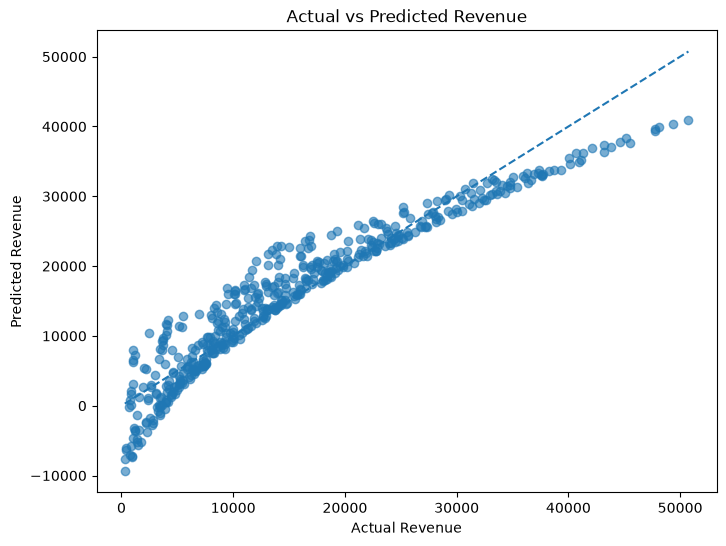

In [90]:
#Now let's visualize the model
#Actual Revenue vs Predicted Revenue
# We'll create a scatter plot.
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.savefig(
    "images/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 8.7 Regression Coefficients

In [91]:
#let's understand which features are influencing your revenue prediction.
#Regression Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)
#Remember our model is roughly:
# Predicted Revenue = Intercept + (Feature × Coefficient) + ...
# The coefficient tells us the direction and size of the relationship while
#  holding the other model features constant.

,Feature,Coefficient
2,tenure_months,912.982643
7,support_intensity,535.709453
1,monthly_fee,17.337241
0,age,9.072040
4,avg_session_time,0.347980
8,engagement_score,-4.450115
5,discount_percent,-12.192574
3,support_tickets,-29.572496
6,plan_rank,-77.123741


## 8.8 Permutation Feature Importance

In [92]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance.importances_mean
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,tenure_months,1.330613
1,monthly_fee,0.597313
7,support_intensity,0.000681
3,support_tickets,0.000182
5,discount_percent,0.000147
0,age,0.000089
4,avg_session_time,-0.000018
8,engagement_score,-0.000158
6,plan_rank,-0.000168


# 9. Final Conclusions & Business Recommendations

## Final Conclusions

This project performed an end-to-end analysis of customer subscription data, covering data cleaning, feature engineering, exploratory data analysis, business analytics, and machine learning.

The analysis examined customer revenue, churn, subscription plans, marketing channels, customer engagement, geographic patterns, and customer acquisition trends.

The machine learning stage used Linear Regression to predict customer total revenue based on selected customer and subscription characteristics.

The model was evaluated using MAE, RMSE, and R², while regression coefficients and permutation feature importance were used to understand the model's relationships with the input features.

## Key Findings

- Customer tenure showed a strong relationship with total revenue.
- Monthly fee was another important variable associated with revenue prediction.
- Churn patterns varied across subscription plans.
- Revenue varied across marketing channels and cities.
- Customer engagement score did not show a strong linear relationship with total revenue in this dataset.
- Permutation feature importance indicated that customer tenure and monthly fee were the most influential features for the revenue prediction model.

## Business Recommendations

Based on the analysis, businesses could:

- Focus on customer retention strategies to encourage longer customer lifetimes.
- Investigate the reasons behind higher churn in specific subscription plans.
- Analyze marketing-channel performance using revenue together with customer acquisition cost and conversion metrics.
- Identify high-value customer segments and develop appropriate retention strategies.
- Monitor customer behavior and engagement to identify potential changes in customer value.
- Continue collecting additional business variables that may improve revenue prediction.

## Project Limitations

- The analysis is based on the available customer subscription dataset.
- The Linear Regression model assumes a linear relationship between the selected features and revenue.
- Some date inconsistencies were identified in the dataset.
- The model should not be interpreted as establishing causal relationships.
- Additional variables and alternative machine-learning models could be evaluated in future work.

## Future Improvements

Future versions of the project could include:

- Testing additional machine-learning algorithms.
- Hyperparameter tuning and model comparison.
- More detailed customer lifetime value analysis.
- Churn prediction as a separate classification problem.
- Interactive dashboards using Power BI or Streamlit.
- Incorporating additional business variables such as acquisition cost, transaction history, and customer satisfaction.